<a href="https://colab.research.google.com/github/Eylz-Liu/Mod-le-vol-locale/blob/main/Delta_hedge_call_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delta hedge d'une position short call : comment se comporte le P&L ?

> **Antonin Chaix**


**L'idée de ce colab est de simuler en Monte Carlo, dans le modèle de Black & Scholes, un grand nombre de trajectoires d'un actif, d'imaginer qu'on vend inititialement un call à la monnaie sur cet actif sous-jacent et qu'on le delta hedge jusqu'à maturité.**

On étudie alors la distribution du P&L de cette stratégie à maturité : moyenne, écart-type, min et max, histogramme. On affiche également les trajectoires conduisant respectivement au moins bon et au meilleur P&L final.

Enfin, on représente sur un graphique les 15 trajectoires conduisant respectivement aux pires et aux meilleurs P&Ls finaux.

Implémentation ci-dessous, explications et analyse à la suite.


SHORT CALL + DELTA HEDGE | 500,000 simulations | 100 pas de temps

Mean P&L = -0.0021
Stdev P&L = 0.6890
Max P&L = 3.8582
Min P&L = -6.9715





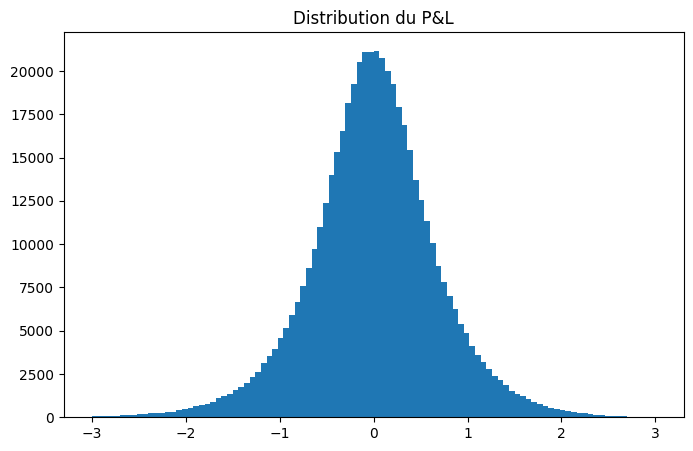



PIRE TRAJECTOIRE EN TERME DE P&L
[100.         100.6525654   96.35337864  96.22471161  96.74977744
  96.01719513  94.45838406  95.92531999  97.55545903  97.66529857
  98.35869459  96.4934813   97.74653646  93.33581727  95.32851195
  92.43522803  91.61968817  86.78952895  88.07467692  87.80623224
  89.40394347  88.37051968  86.75045335  82.82695629  82.44334001
  84.27692808  86.12645898  85.84954259  86.48975535  84.92910479
  82.63971657  85.52009434  84.76421305  84.361757    85.68241579
  86.14252705  85.54521013  88.33716299  88.21541941  85.11541331
  86.70747566  86.91866177  83.81407018  83.79944889  85.23426605
  85.20935015  88.38164061  89.32972437  89.02927506  86.89184368
  89.02048267  88.66348071  90.1927992   88.338878    89.13376143
  89.63909349  89.78627175  92.20033601  91.2817339   90.83378145
  96.03406379  95.34167508  94.70594777  93.72607834  96.06422451
  99.45090806 102.06832167 100.70686792  98.95513012 101.10127237
 101.51430965  99.35845894 100.75373254 1

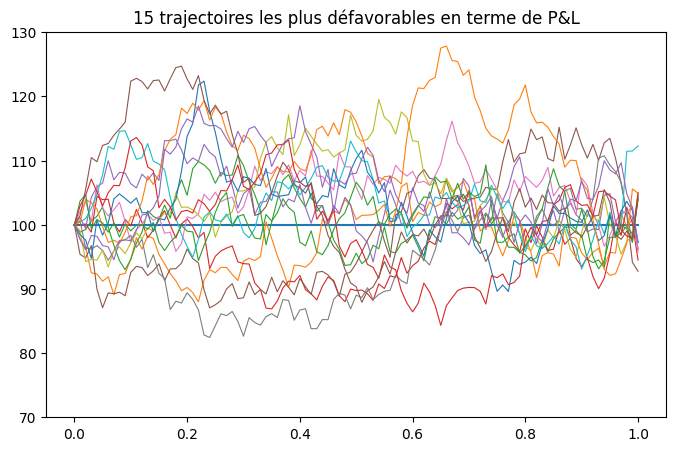

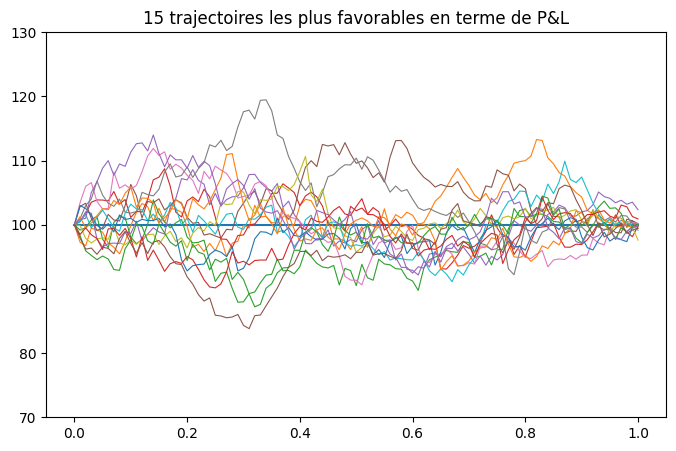

In [ ]:

import numpy as np
import math
import time
from scipy.stats import norm
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 5)

# BS formula for a call
def bs_call(T, K, S0, sigma, r) :
    if (T==0 or sigma==0) : return max(S0-K, 0)
    sigma_sqrt_T = sigma * math.sqrt(T)
    d1 = (math.log(S0/K) + (r + 0.5 * sigma**2) * T) / sigma_sqrt_T
    d2 = d1 - sigma_sqrt_T
    return S0 * norm.cdf(d1) - K * math.exp(-r*T) * norm.cdf(d2)

# BS formula for a call
# made numpy comptatible
def bs_call_delta(T, K, S0, sigma, r) :
    d1 = (np.log(S0/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# option params
T = 1.
K = 100
S0 = 100
r = 0.015

# input real drift & vols
drift_real  = 0.06 # drift avec lequel est diffusé l'actif sous-jacent
sigma_real  = 0.20 # volatilité réalisée
sigma_price = 0.20 # vol implicite à laquelle est vendu le call
sigma_hedge = 0.20 # vol avec laquelle on se hedge (i.e. vol avec laquelle on calcule le delta)

# MC params
Nsimul = 5*10**5
Nsteps = 100

print("SHORT CALL + DELTA HEDGE | {:,} simulations | {} pas de temps".format(Nsimul, Nsteps))
print("==================================================================")

t = np.linspace(0, T, Nsteps+1, endpoint=True)
dt = T / Nsteps
capit = math.exp(r * dt)
A = (drift_real - 0.5  * sigma_real**2) * dt
B = sigma_real * math.sqrt(dt)

normal = np.random.normal(0, 1, (Nsteps, Nsimul))

S = np.empty(shape=(Nsteps + 1, Nsimul))
cash = np.empty(shape=(Nsteps + 1, Nsimul))
S[0,:] = S0

t0 = time.time()

# generate underlying
for j in range(Nsteps) :
    S[j+1,:] = S[j,:] * np.exp(A + B * normal[j,:])

# delta sur toute la trajetoire (jusqu'en T - dt) et toutes les simulations
delta = bs_call_delta(T-t[:-1, np.newaxis], K, S[:-1,:], sigma_hedge, r)

# cash initial = vente call + delta hedge initial
cash[0,:] = bs_call(T, K, S0, sigma_price, r) - delta[0,:] * S0

# ajustement de la couverture à chaque pas de temps
for j in range(Nsteps-1) :
    cash[j+1,:] = cash[j,:] * capit - S[j+1,:] * (delta[j+1,:] - delta[j,:])

# debouclage à maturité
cash[-1,:] = cash[-2,:] * capit - np.maximum(S[-1,:]-K, 0.) +  delta[-1,:] * S[-1,:] # delta[-1,:] est bien le delta à la date T-dt, car delta a une colonne de moins

print()
print("Mean P&L = {:.4f}".format(np.mean(cash[-1,:])))
print("Stdev P&L = {:.4f}".format(np.std(cash[-1,:])))
print("Max P&L = {:.4f}".format(np.max(cash[-1,:])))
print("Min P&L = {:.4f}".format(np.min(cash[-1,:])))

#print("\ncomput. time = {:2f}".format(time.time()-t0))

print("\n\n")

# histogramme
plt.hist(cash[-1,:], bins = 100, range=(-3,3))
plt.title("Distribution du P&L")
plt.show()

# affichage pire et meilleure trajectoire : tout se joue sur la vol réalisée au voisinage du strike à la fin
print("\n\nPIRE TRAJECTOIRE EN TERME DE P&L\n===========================================")
index = int(np.argpartition(cash[-1,:],1)[:1][0])
print(S[:,index])
print()
print("Vol réalisée sur toute la trajectoire = {:.2f}%".format(100*np.std(np.log(S[1:, index]/S[:-1, index]))/math.sqrt(dt)))
print("Vol réalisée sur les 15 derniers pas de temps = {:.2f}%".format(100*np.std(np.log(S[-15:, index]/S[-16:-1, index]))/math.sqrt(dt)))
print("\n\n")

print("MEILLEURE TRAJECTOIRE EN TERME DE P&L\n===========================================")
index = int(np.argpartition(cash[-1,:],-1)[-1:][0])
print(S[:,index])
print()
print("Vol réalisée sur toute la trajectoire = {:.2f}%".format(100*np.std(np.log(S[1:, index]/S[:-1, index]))/math.sqrt(dt)))
print("Vol réalisée sur les 15 derniers pas de temps = {:.2f}%".format(100*np.std(np.log(S[-15:, index]/S[-16:-1, index]))/math.sqrt(dt)))
print("\n\n")

# ==== GRAPHS ====
nb_traj = 15 # nbre de trajectoires affichées
nb_values_plotted = Nsteps+1 # on plot les nb_values_plotted dernières valeurs de la trajectoire

# on repère où le P&L est le plus petit pour afficher les trajectoires d'actif correspondantes
min_indexes = np.argpartition(cash[-1,:],nb_traj)[:nb_traj]

# on repère où le P&L est le plus grand pour afficher les trajectoires d'actif correspondantes
max_indexes = np.argpartition(cash[-1,:],-nb_traj)[-nb_traj:]

# Affichage des pires trajectoires
plt.plot(t[-nb_values_plotted:], np.full(nb_values_plotted, K)) # pour matérialiser le strike
plt.plot(t[-nb_values_plotted:], S[-nb_values_plotted:, min_indexes], linewidth=0.8)
plt.title("{} trajectoires les plus défavorables en terme de P&L".format(nb_traj))
plt.ylim(70, 130)
plt.show()

print("\n")

# Affichage des meilleures trajectoires
plt.plot(t[-nb_values_plotted:], np.full(nb_values_plotted, K)) # pour matérialiser le strike
plt.plot(t[-nb_values_plotted:], S[-nb_values_plotted:, max_indexes], linewidth=0.8)
plt.title("{} trajectoires les plus favorables en terme de P&L".format(nb_traj))
plt.ylim(70, 130)
plt.show()

# Rappels sur le delta hedge des options

Lorsque l'on vend un call ou un put, on est **gamma négatif**, autrement dit la convexité du prix de l'option joue contre nous. En effet :

* Quand l'actif sous-jacent monte, la variation du delta de l'option implique qu'il faut acheter de l'actif pour ajuster sa couverture

* Quand l'actif sous-jacent baisse, la variation du delta de l'option implique qu'il faut vendre de l'actif pour ajuster sa couverture


**En achetant ainsi à la hausse et vendant à la baisse, on perd  de l'argent sur chacun des réajustements de notre hedge en delta.** Mais en contrepartie, on a vendu l'option initialement, et reçu une prime pour cela. **On espère donc que la prime reçue compensera les pertes subies tout au long de la vie de l'option via les réajustement du delta hedge**.

Les pertes subies sur la couverture vont être d'autant plus importantes que l'actif fluctue beaucoup dans la zone de fort gamma, c'est à dire proche du strike, à mesure qe l'on se rapproche de la maturité. **Autrement dit, ce qui détermine le coût de la couverture est la *volatilité réalisée* dans cette zone de fort gamma**.

D'autre part, la prime perçue initialement est liée à la ***volatilité implicite*** à laquelle on a vendu l'option.

C'est la raison pour laquelle on décrit souvent le P&L d'un delta hedge d'option par l'expression ***vol implicite vs. vol réalisée***.

Mais on peut également décrire sur P&L comme ***Gamma vs. Thêta*** car chaque jour :
* On encaisse du thêta (i.e. au total on encaisse la prime)
* On perd sur les réajustements en delta (d'autant plus que le gamma est important et que les variations de l'actif sont grandes)

On peut d'ailleurs voire les choses plus mathématiquement de la façon suivante. Supposons, pour simplifier, qu'il n'y ait pas de taux d'intêrêt. La P&L réalisé entre $t$ et $t+\delta t$ est la variation du prix de l'option vendue (ici un call) ainsi que celle du delta hedge :

$$
V_{t+\delta t}=-(C_{t+\delta t}-C_t) + \Delta_t (S_{t+\delta t} - S_t)
$$

Développement limité à l'ordre 2 du prix de l'option en utilisant le thêta, le delta et le gamma :

$$
C_{t+\delta t}-C_t\approx \theta_t\,\delta t + \Delta_t (S_{t+\delta t} - S_t) + \frac{1}{2}\,\Gamma_t\, (S_{t+\delta t} - S_t)^2
$$

En reportant dans la première relation, la partie en delta disparaît et il reste :

$$
V_{t+\delta t}\;\approx\; -\theta_t \,\delta t \;-\; \frac{1}{2}\,\Gamma_t\, (S_{t+\delta t} - S_t)^2
$$

Cette relation illustre parfaitement ce qu'on expliquait. La grandeur $\theta_t$ est négative (un call ou put est thêta négatif), donc sur chaque intervalle, le terme $-\theta_t \,\delta t$ est positif *i.e*. on encaisse mécaniquement du thêta. A l'inverse on perd sur le réajustement du hedge d'autant plus que 1/ le gamma est important et 2/ la variation (quadratique) de l'actif est grande. **La volatilité réalisée dans les zones de fort gamma est bien ce qui va déterminer le coût de la couverture et donc le P&L dans le cas de notre delta hedge.**

On peut même réécrire la relation ci-dessus de façon encore plus parlante. En effet sous Black & Scholes on a  $\Gamma_t=\frac{n(d_1)}{S_t\sigma\sqrt{T-t}}$, et lorsque $r=0$, le thêta sécrit $\theta_t=-\frac{\sigma S_t\, n(d_1)}{2\sqrt{T-t}}$, d'où la relation entre $\Gamma$ et $\theta$ :  
$$
\theta_t= -\frac{1}{2}\,\sigma^2 \,S_t^2\,\Gamma_t
$$
En remplaçant $\theta_t$ dans l'expression du P&L obtenue précédemment tombe donc sur :
$$
V_{t+\delta t} \approx\; \frac{1}{2}\,S_t^2\, \Gamma_t\left(\sigma^2\delta t - \left(\frac{S_{t+\delta t} - S_t}{S_t}\right)^2 \right)
$$

Cette fois-ci le P&L apparait comme **la différence entre la variance implicite $\sigma^2\delta t$ et la variance réalisée $\left(\frac{S_{t+\delta t} - S_t}{S_t}\right)^2$, cette différence étant pondérée par le gamma de l'option**. On retombe donc de façon encore plus claire sur le résultat précédent : lorsqu'on vend une option et la delta hedge, la position est gagnante lorsque la volatilité réalisée est plus faible que la volatilité implicite, et ce d'autant plus que l'on se situe dans la zone de fort gamma (i.e. à la monnaie et proche de la maturité de l'option).


# Analyse des résultats

Tout d'abord, remarquons que le P&L présente une **dispersion importante**. Cela est uniquement dû au fait qu'on se réajuste en delta à des dates discrètes.

Pour vous en convaincre, réalisez quelques simulations avec 1 million de pas de temps  (juste quelques unes, sinon ça prendra un temps infini !) : **vous constaterez qu'à chaque fois le P&L obtenu est nul**. Cela est bien sûr dû au fait que la vol réalisée (celle avec laquelle on simule les trajectoires), la vol de pricing (celle à laquelle on vend le call) et la vol de hedging (celle avec laquelle on calcule le delta tout au long de la trajectoire) sont égales. Si on change la vol de pricing, cela décale tout simplement le P&L de la variation du prix du call. Plus intéressant, si on prend un vol de hedging différente, qu'elle soit plus faible ou plus importante, cela va dégrader le P&L final (il sera dans les deux cas négatif). Autrement dit, **il est sous-optimal de hedger une option avec une volatilité différente de la volatilité réélle de l'actif sous-jacent**.

Revenons à présent au cas d'un delta hedge à des dates discrètes. Vous remarquez que dans le cas où les trois volatilités ci-dessus sont égales, **la moyenne du P&L final observé est nul**. Pour 100 pas de temps, la dispersion observée est importante et légèrement asymétrique (|min| > |max|).

Autre propriété fondamentale, et c'est la magie de la réplication des options : **la distribution du P&L ne varie pas lorsqu'on modifie le drift réél de l'actif sous-jacent**. La stratégie de couverture est efficace quelle que soit la tendance de l'actif.

On constate en étudiant la trajectoire conduisant au P&L le plus défavorable qu'elle oscille fortement au voisinage du strike dans les jours derniers jours précédant la maturité de l'option (on le voit aussi très clairement sur le graphique représentant les 15 trajectoires les plus défavorables). Cela confirme ce que l'on a expliqué plus tôt : **la couverture (i.e. les réajustements en delta) coûte d'autant plus cher que l'actif varie beaucoup dans la zone de fort gamma, c'est à dire proche du strike et de la maturité.**

Concernant les trajectoires les plus favorables au P&L on pourrait penser (c'était mon intuition et je ne suis pas le seul) qu'elles seraient celles avec une faible volatilité réalisée et qui aboutiraient à maturité très en dehors ou dans la monnaie, i.e. dans des zones où le gamma est nul (c'est à dire où le delta ne bouge plus). Mais il n'en est rien ! **Les trajectoires qui rapportent le plus sont aussi celles qui aboutissent au niveau du strike à la maturité, mais pour lesquelles la volatilité réalisée proche de la maturité est très faible.**

On pouvait en réalité le deviner au regard de la relation vue précédemment :

$$
V_{t+\delta t} \approx\; \frac{1}{2}\,S_t^2\, \Gamma_t\left(\sigma^2\delta t - \left(\frac{S_{t+\delta t} - S_t}{S_t}\right)^2 \right)
$$


Les trajectoires les plus favorables en terme de P&L sont effectivement celles où $\left(\frac{S_{t+\delta t} - S_t}{S_t}\right)^2\ll\sigma^2\delta t\;$ (variance réalisée très inférieure à la variance implicite) dans la zone de fort gamma, i.e. lorsqu'on est très proche de la maturité de l'option avec le sous-jacent au voisinage du strike.

Regardez la trajectoire conduisant au meilleur P&L et le graphe représentant 15 trajectoires les plus favorables, c'est exactement ça...